<a href="https://colab.research.google.com/github/aysenuruyar-rgb/DSA210-Proj/blob/main/notebook/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DAM DATA


,DATE,GENERAL_DAM_OCCUPANCY_RATE,GENERAL_DAM_RESERVED_WATER
0,2005-01-01,44.62,388
1,2005-01-02,44.62,388
2,2005-01-03,44.47,386
3,2005-01-04,44.42,386
4,2005-01-05,44.35,385


WEATHER DATA


,time,precipitation_sum (mm),temperature_2m_mean (°C),rain_sum (mm)
0,2000-01-27,0.0,-3.0,0.0
1,2000-01-28,0.0,1.6,0.0
2,2000-01-29,0.0,2.2,0.0
3,2000-01-30,0.0,6.7,0.0
4,2000-01-31,0.0,8.0,0.0


/tmp/ipykernel_728/3998275217.py:42: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dam_monthly = dam.resample("M").mean()
/tmp/ipykernel_728/3998275217.py:44: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  weather_monthly = weather.resample("M").agg({


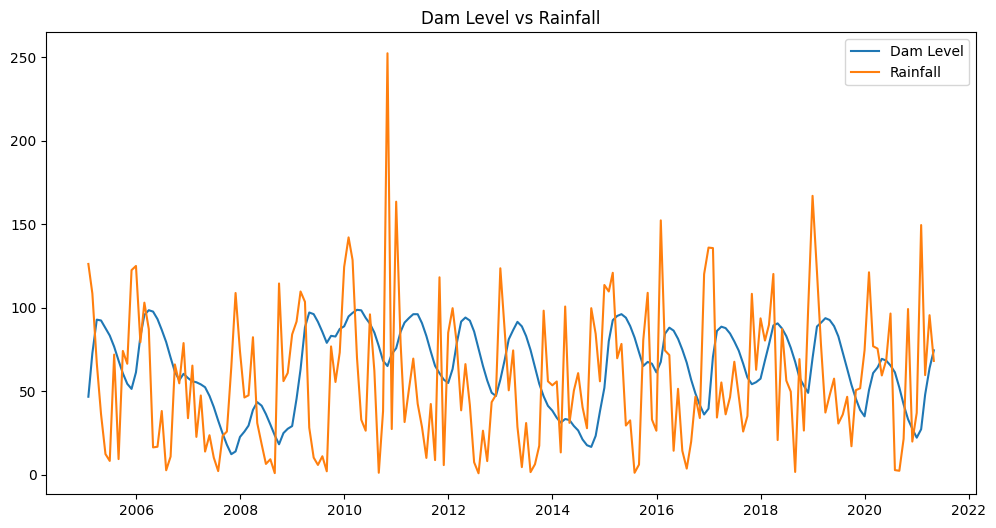

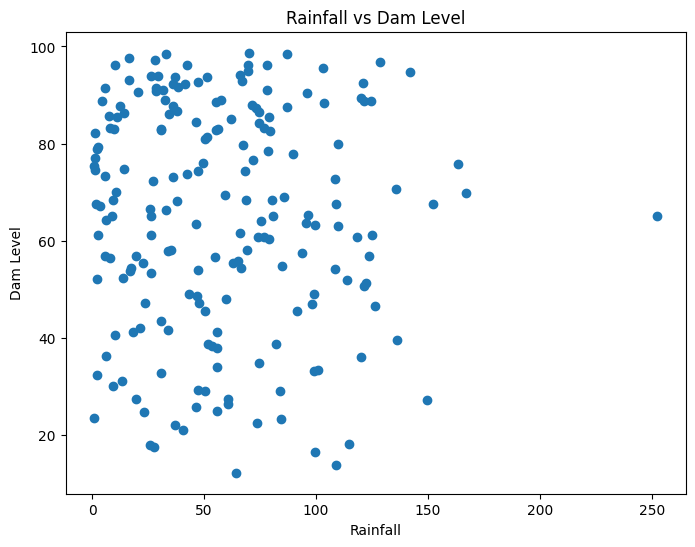

Correlation: -0.03922919964181322
P-value: 0.5851305052748212
                            OLS Regression Results                            
Dep. Variable:                    dam   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.2990
Date:                Sun, 12 Apr 2026   Prob (F-statistic):              0.585
Time:                        15:55:30   Log-Likelihood:                -893.86
No. Observations:                 196   AIC:                             1792.
Df Residuals:                     194   BIC:                             1798.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr

dam_url = "dam_occupancy.csv"
weather_url = "open-meteo-41.02N29.02E48m (1).csv"

dam = pd.read_csv(dam_url)
weather = pd.read_csv(weather_url, skiprows=2)

print("DAM DATA")
display(dam.head())

print("WEATHER DATA")
display(weather.head())



dam["DATE"] = pd.to_datetime(dam["DATE"])
dam = dam.set_index("DATE")

dam = dam.rename(columns={
    "GENERAL_DAM_OCCUPANCY_RATE": "dam",
    "GENERAL_DAM_RESERVED_WATER": "water"
})



weather["time"] = pd.to_datetime(weather["time"])
weather = weather.set_index("time")

weather = weather.rename(columns={
    "precipitation_sum (mm)": "precip",
    "temperature_2m_mean (°C)": "temp",
    "rain_sum (mm)": "rain"
})


dam_monthly = dam.resample("M").mean()

weather_monthly = weather.resample("M").agg({
    "precip": "sum",
    "rain": "sum",
    "temp": "mean"
})



df = dam_monthly.merge(weather_monthly, left_index=True, right_index=True)

df.head()

plt.figure(figsize=(12,6))

plt.plot(df.index, df["dam"], label="Dam Level")
plt.plot(df.index, df["precip"], label="Rainfall")

plt.legend()
plt.title("Dam Level vs Rainfall")
plt.show()


plt.figure(figsize=(8,6))
plt.scatter(df["precip"], df["dam"])

plt.xlabel("Rainfall")
plt.ylabel("Dam Level")
plt.title("Rainfall vs Dam Level")

plt.show()

df.corr()


corr, p = pearsonr(df["precip"], df["dam"])

print("Correlation:", corr)
print("P-value:", p)


X = df[["precip"]]
X = sm.add_constant(X)

y = df["dam"]

model = sm.OLS(y, X).fit()
print(model.summary())


X2 = df[["precip", "temp"]]
X2 = sm.add_constant(X2)

model2 = sm.OLS(df["dam"], X2).fit()
print(model2.summary())


